In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style for better aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load the data directly from the CSV file
df_env = pd.read_csv('results_env_sizes.csv')

# Create a descriptive label for the x-axis
df_env['env_label'] = df_env.apply(lambda row: f"{row['width']}x{row['height']}, {row['num_agents']} Agents", axis=1)

# Separate data for easier plotting and sort by environment size
df_cen_env = df_env[df_env['run_name'] == 'Centralized'].sort_values('width')
df_dec_env = df_env[df_env['run_name'] == 'Decentralized'].sort_values('width')

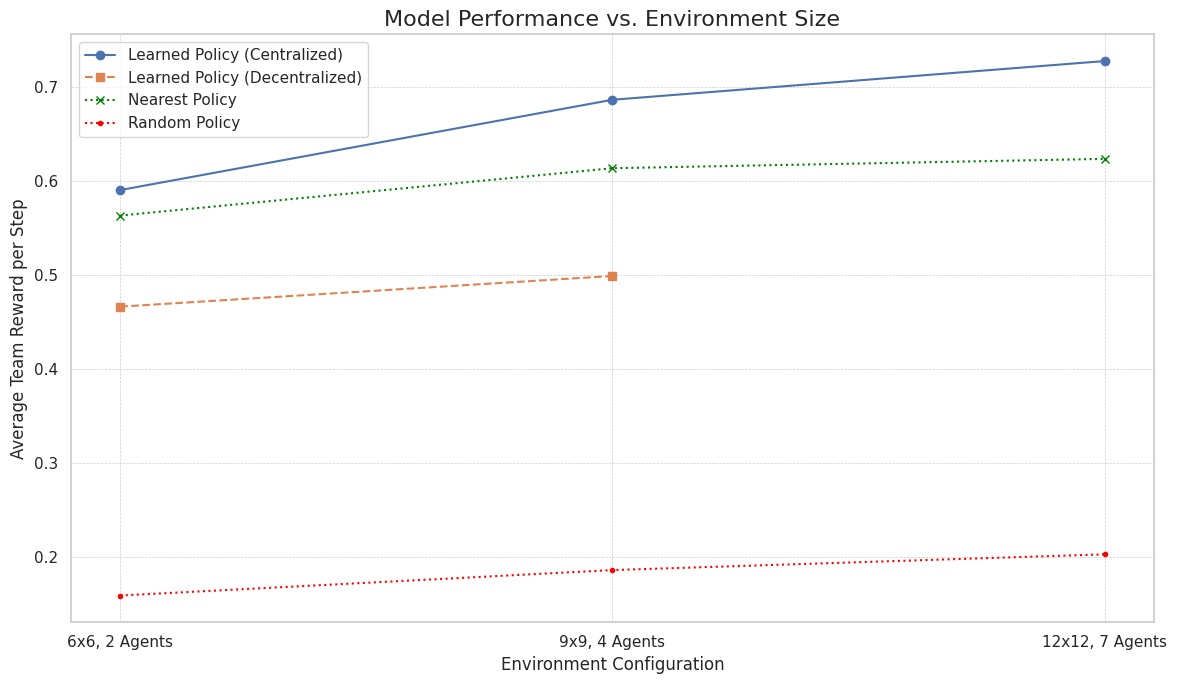

In [5]:
plt.figure(figsize=(12, 7))

# Centralized Results
plt.plot(df_cen_env['env_label'], df_cen_env['mean_learned_reward'], marker='o', linestyle='-', label='Learned Policy (Centralized)')

# Decentralized Results
plt.plot(df_dec_env['env_label'], df_dec_env['mean_learned_reward'], marker='s', linestyle='--', label='Learned Policy (Decentralized)')

# Baselines (plotting the specific values from each run for accuracy)
plt.plot(df_cen_env['env_label'], df_cen_env['mean_nearest_reward'], marker='x', linestyle=':', color='green', label='Nearest Policy')
plt.plot(df_cen_env['env_label'], df_cen_env['mean_random_reward'], marker='.', linestyle=':', color='red', label='Random Policy')

plt.title('Model Performance vs. Environment Size', fontsize=16)
plt.xlabel('Environment Configuration', fontsize=12)
plt.ylabel('Average Team Reward per Step', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

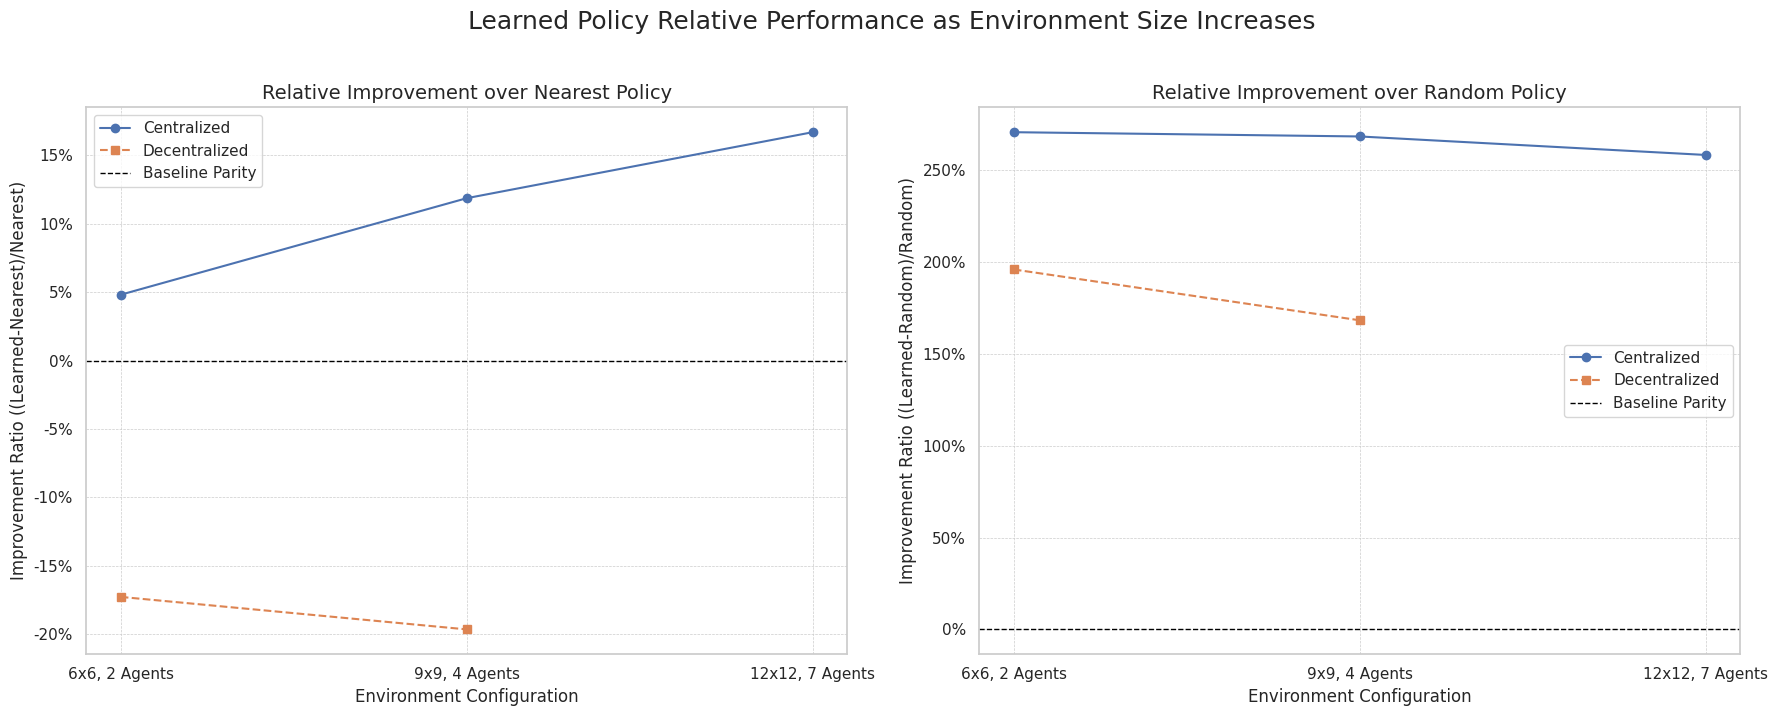

In [7]:
# Calculate relative improvement metrics
for df in [df_cen_env, df_dec_env]:
    df['rel_vs_nearest'] = (df['mean_learned_reward'] - df['mean_nearest_reward']) / df['mean_nearest_reward']
    df['rel_vs_random'] = (df['mean_learned_reward'] - df['mean_random_reward']) / df['mean_random_reward']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Relative Improvement over Nearest Policy
ax1.plot(df_cen_env['env_label'], df_cen_env['rel_vs_nearest'], marker='o', label='Centralized')
ax1.plot(df_dec_env['env_label'], df_dec_env['rel_vs_nearest'], marker='s', linestyle='--', label='Decentralized')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, label='Baseline Parity')
ax1.set_title('Relative Improvement over Nearest Policy', fontsize=14)
ax1.set_xlabel('Environment Configuration', fontsize=12)
ax1.set_ylabel('Improvement Ratio ((Learned-Nearest)/Nearest)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
ax1.legend()
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot 2: Relative Improvement over Random Policy
ax2.plot(df_cen_env['env_label'], df_cen_env['rel_vs_random'], marker='o', label='Centralized')
ax2.plot(df_dec_env['env_label'], df_dec_env['rel_vs_random'], marker='s', linestyle='--', label='Decentralized')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, label='Baseline Parity')
ax2.set_title('Relative Improvement over Random Policy', fontsize=14)
ax2.set_xlabel('Environment Configuration', fontsize=12)
ax2.set_ylabel('Improvement Ratio ((Learned-Random)/Random)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
ax2.legend()
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.suptitle('Learned Policy Relative Performance as Environment Size Increases', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Load the data directly from the CSV file
df_model = pd.read_csv('results.csv')

# Calculate average baselines
avg_random = df_model['mean_random_reward'].mean()
avg_nearest = df_model['mean_nearest_reward'].mean()

# Define a function to create a descriptive model label
def create_model_label(row):
    conv = row['conv_channels']
    mlp_feat = row['mlp_features']
    mlp_lay = row['mlp_layers']
    k = row['kernel_size']
    return f"Conv:{conv} | MLP:{mlp_feat}x{mlp_lay} | k={k}"

df_model['model_label'] = df_model.apply(create_model_label, axis=1)

# Define the desired order of models from smallest to largest for plotting
model_order = [
    'Conv:1 | MLP:1x0 | k=1',          # Point
    'Conv:1 | MLP:1x1 | k=1',          # Point+
    'Conv:1 | MLP:1x1 | k=3',          # Tiny
    'Conv:4 | MLP:8x1 | k=3',          # Tiny+
    'Conv:8-16 | MLP:32x2 | k=3',      # Small
    'Conv:16-32-32 | MLP:128x2 | k=3', # Medium
    'Conv:32-64-64 | MLP:128x2 | k=3'  # Large
]

# Separate and prepare data for plotting
# Using .reindex() is safer than .loc[] if some models are missing from the CSV
df_cen_model = df_model[df_model['run_name'] == 'Centralized'].set_index('model_label').reindex(model_order).reset_index()
df_dec_model = df_model[df_model['run_name'] == 'Decentralized'].set_index('model_label').reindex(model_order).reset_index()

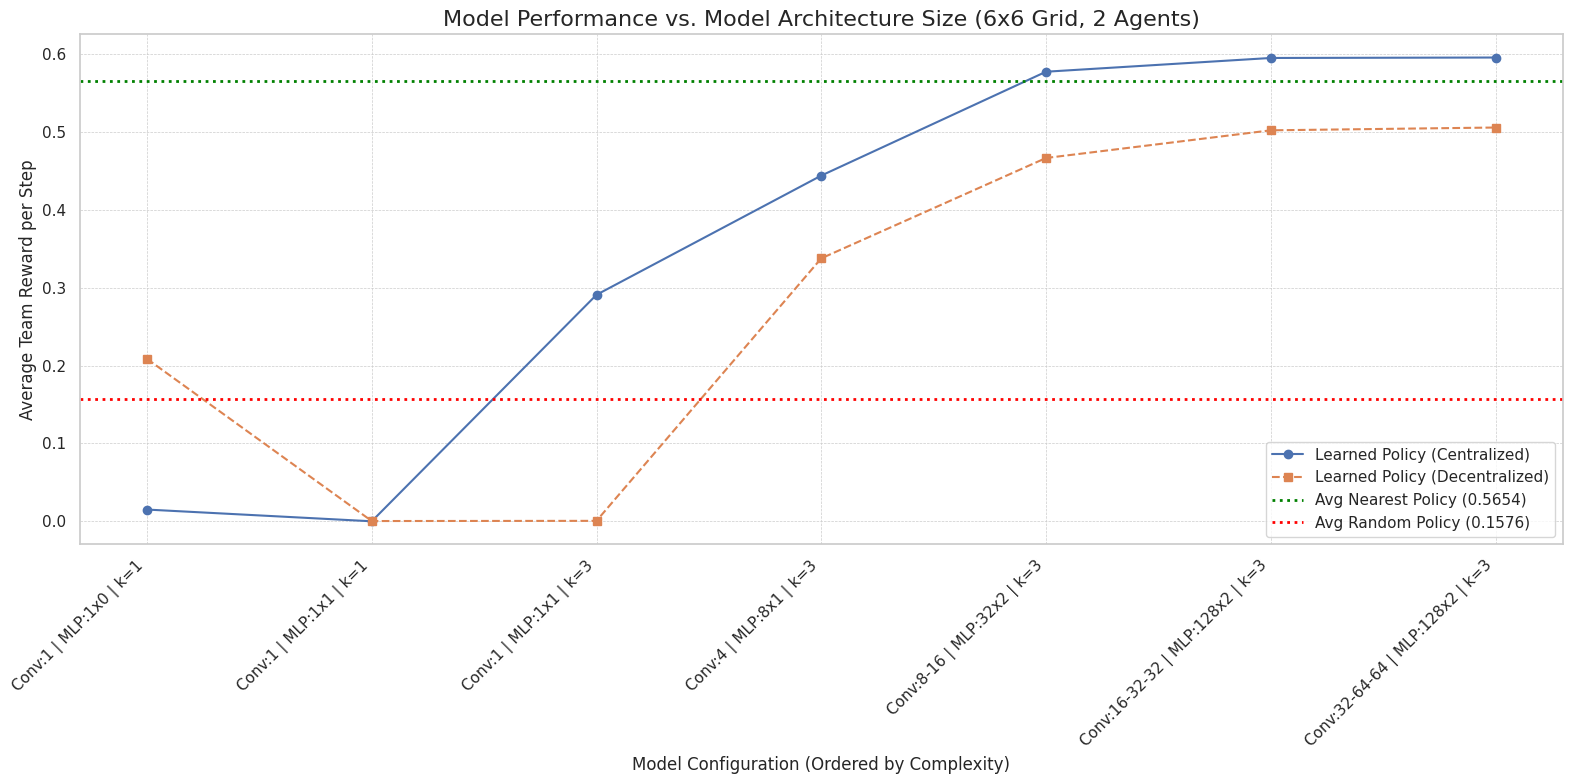

In [9]:
plt.figure(figsize=(16, 8))

plt.plot(df_cen_model['model_label'], df_cen_model['mean_learned_reward'], marker='o', linestyle='-', label='Learned Policy (Centralized)')
plt.plot(df_dec_model['model_label'], df_dec_model['mean_learned_reward'], marker='s', linestyle='--', label='Learned Policy (Decentralized)')

# Plot average baselines as horizontal lines
plt.axhline(avg_nearest, color='green', linestyle=':', linewidth=2, label=f'Avg Nearest Policy ({avg_nearest:.4f})')
plt.axhline(avg_random, color='red', linestyle=':', linewidth=2, label=f'Avg Random Policy ({avg_random:.4f})')

plt.title('Model Performance vs. Model Architecture Size (6x6 Grid, 2 Agents)', fontsize=16)
plt.xlabel('Model Configuration (Ordered by Complexity)', fontsize=12)
plt.ylabel('Average Team Reward per Step', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()